In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [7]:
df = pd.read_csv("student-mat.csv", sep=";")

print(f"Toplam öğrenci sayısı: {df.shape[0]}, Sütun sayısı: {df.shape[1]}")


Toplam öğrenci sayısı: 395, Sütun sayısı: 33


In [8]:
df.head(2)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6


In [11]:
y = df["G3"]
# Burada x için "y hariç hepsi x'im olsun" diyemememin sebebi sayısal olmayan sütunlarımın bulunması
X = df[["G1", "G2", "studytime", "failures", "absences", "age","freetime","goout"]]


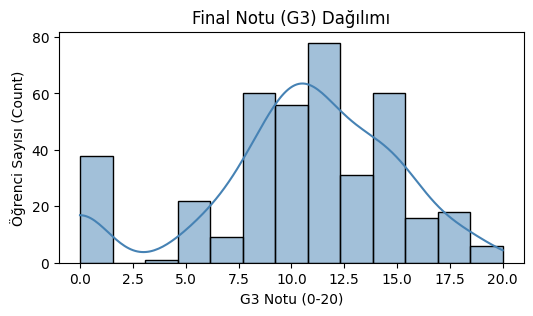

In [12]:
# Gemini yaptı bu kısmı, hiç anlamıyom tablolardan: Hedef değişkenin dağılımına bakalım (hocanın ilk çizdirdiği gibi)
plt.figure(figsize=(6, 3))
sns.histplot(y, kde=True, color="steelblue")
plt.title("Final Notu (G3) Dağılımı")
plt.xlabel("G3 Notu (0-20)")
plt.ylabel("Öğrenci Sayısı (Count)")
plt.show()

#### Train - test split yapalım

In [13]:
from sklearn.model_selection import train_test_split

# 80'e 20 yapak
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### Baseline ve lineer regresyon kuralım

In [14]:
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression

# Baseline: Tembel model (sadece y_train ortalamasını alacak)
baseline = DummyRegressor(strategy="mean").fit(X_train, y_train)

# Linear: Gerçek model (X değişkenlerine göre katsayı öğrenecek)
linear = LinearRegression().fit(X_train, y_train)

#### RAPOR: Bakalım nolmuş

In [15]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


def regresyon_raporu(model, X, y, ad):
  tahmin = model.predict(X)
  return {
      "Model": ad,
      "MAE": round(mean_absolute_error(y, tahmin), 3),
      "MSE": round(mean_squared_error(y, tahmin), 3),
      "RMSE": round(np.sqrt(mean_squared_error(y, tahmin)), 3),
      "R2": round(r2_score(y, tahmin), 3),
  }


sonuc = pd.DataFrame([
    regresyon_raporu(baseline, X_test, y_test, "Baseline"),
    regresyon_raporu(linear, X_test, y_test, "Linear Regression"),
])

print(sonuc)

               Model    MAE     MSE   RMSE     R2
0           Baseline  3.646  20.704  4.550 -0.010
1  Linear Regression  1.371   4.607  2.146  0.775
